<a href="https://colab.research.google.com/github/Iditc/log-anomaly-detection/blob/main/notebooks/05_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Define paths and imports
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path('/content/drive/MyDrive/log-anomaly-detection')
DATA_PROC = BASE / 'data' / 'processed'
RESULTS = BASE / 'results'

In [3]:
# Load block-level count vectors and full parsed data
df_blocks = pd.read_parquet(DATA_PROC / "hdfs_block_vectors.parquet")
df_full = pd.read_parquet(DATA_PROC / "hdfs_full_parsed.parquet")
print(f"Blocks: {df_blocks.shape}")
print(f"Full log: {df_full.shape}")

Blocks: (575061, 56)
Full log: (11175629, 4)


In [4]:
# Define which templates to keep as individual features
keep_templates = ['t_1', 't_2', 't_4', 't_10', 't_11', 't_13', 't_16', 't_17',
                  't_21', 't_32', 't_33', 't_34', 't_35', 't_37', 't_38', 't_47', 't_48', 't_50']

# Templates that only appear in anomaly blocks
anomaly_only_templates = ['t_7', 't_8', 't_14', 't_15', 't_18', 't_19', 't_20',
                          't_22', 't_23', 't_25', 't_26', 't_27', 't_28', 't_29',
                          't_30', 't_39', 't_40', 't_41', 't_42', 't_43', 't_44',
                          't_45', 't_46', 't_51', 't_52', 't_53', 't_54', 't_55']

template_cols = [c for c in df_blocks.columns if c.startswith("t_")]

# Start with the 18 selected templates
df_features = df_blocks[keep_templates].copy()

# Feature 19: total log lines per block
df_features["total_lines"] = df_blocks[template_cols].sum(axis=1)

# Feature 20: short block (1 if less than 10 lines)
df_features["short_block"] = (df_features["total_lines"] < 10).astype(int)

# Feature 21: unique templates in block
df_features["unique_templates"] = (df_blocks[template_cols] > 0).sum(axis=1)

# Feature 22: has error template (t_32)
df_features["has_error_template"] = (df_blocks["t_32"] > 0).astype(int)

# Feature 23: has replication (t_11)
df_features["has_replication"] = (df_blocks["t_11"] > 0).astype(int)

# Feature 24: last template per block
last_template = df_full.groupby("block_id")["template_id"].last()
df_features["last_template"] = last_template.values

# Feature 25: missing lifecycle (t_4 or t_5 absent)
df_features["missing_lifecycle"] = ((df_blocks["t_4"] == 0) | (df_blocks["t_5"] == 0)).astype(int)

# Feature 26: count of anomaly-only templates
df_features["anomaly_only_count"] = (df_blocks[anomaly_only_templates] > 0).sum(axis=1)

# Add label
df_features["Label"] = df_blocks["Label"]

print(f"Final feature matrix: {df_features.shape}")
print(f"\nColumns:\n{list(df_features.columns)}")

Final feature matrix: (575061, 27)

Columns:
['t_1', 't_2', 't_4', 't_10', 't_11', 't_13', 't_16', 't_17', 't_21', 't_32', 't_33', 't_34', 't_35', 't_37', 't_38', 't_47', 't_48', 't_50', 'total_lines', 'short_block', 'unique_templates', 'has_error_template', 'has_replication', 'last_template', 'missing_lifecycle', 'anomaly_only_count', 'Label']


In [5]:
# Save engineered features to parquet
df_features.to_parquet(DATA_PROC / "hdfs_features.parquet")
print("Saved to hdfs_features.parquet")

Saved to hdfs_features.parquet


Training Isolation Forest with 26 features...
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    558223
     Anomaly       0.75      0.75      0.75     16838

    accuracy                           0.99    575061
   macro avg       0.87      0.87      0.87    575061
weighted avg       0.99      0.99      0.99    575061



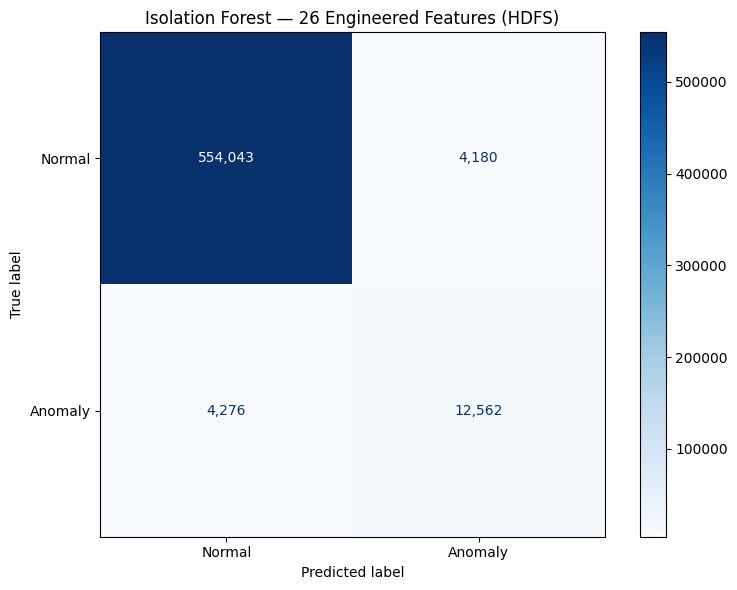

In [6]:
# Train Isolation Forest with engineered features
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df_features.drop(columns=["Label"]).values
y = (df_features["Label"] == "Anomaly").astype(int).values

print("Training Isolation Forest with 26 features...")
model = IsolationForest(
    n_estimators=100,
    contamination=0.0293,
    random_state=42,
    n_jobs=-1
)
model.fit(X)

y_pred = (model.predict(X) == -1).astype(int)

print(classification_report(y, y_pred, target_names=["Normal", "Anomaly"]))

# Confusion matrix plot
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.set_title("Isolation Forest — 26 Engineered Features (HDFS)")
plt.tight_layout()
plt.savefig(str(RESULTS / "if_engineered_confusion_matrix.png"), dpi=150)
plt.show()